In [1]:
# jax ecosystem
import jax

# # jax.config.update("jax_enable_x64", False)
jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_platform_name", "gpu")
# jax.config.update("jax_debug_nans", False)

# device = jax.local_devices()[0]
# print(device.device_kind)

# stats = device.memory_stats()
# free = stats["bytes_limit"] - stats["bytes_in_use"]
# print(f"Total VRAM : {stats['bytes_limit'] / 1024**3:.2f} GB")
# print(f"In use     : {stats['bytes_in_use'] / 1024**3:.2f} GB")
# print(f"Free       : {free / 1024**3:.2f} GB")

import jax.numpy as np
import jax.tree as jtu
import jax.random as jr

# amigo
import dorito
import amigo
import dLux
import zodiax

# matplotlib ecosystem
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

# other
import pandas as pd
import os
import sys

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
# plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

def get_cmap(cmap_name: str):
    cmap = mpl.colormaps[cmap_name]
    cmap.set_bad("k", 0.5)
    return cmap

inferno = get_cmap("inferno")
seismic = get_cmap("seismic")
coolwarm = get_cmap("coolwarm")

if jax.config.read("jax_enable_x64"):
    print("64bit enabled")
else:
    print("32bit enabled")

import equinox
import lineax

print("jax version:", jax.__version__)
print("equinox version:", equinox.__version__)
print("lineax version", lineax.__version__)
print("zodiax version:", zodiax.__version__)
print("dLux version:", dLux.__version__)
print("amigo version:", amigo.__version__)
print("dorito version:", dorito.__version__)

64bit enabled
jax version: 0.8.3
equinox version: 0.13.7
lineax version 0.1.0
zodiax version: 0.5.0
dLux version: 0.15.0
amigo version: 0.0.10
dorito version: 0.2.0


# Loading in data

In [2]:
# Setting data path
from socket import gethostname
from retrain_fns import Tee

print(f"host name: {gethostname()}")

if (
    gethostname() == "maxs-mbp-14.shared.sydney.edu.au"
    or gethostname() == "Maxs-MacBook-Pro-14.local"
):
    data_dir = "/Volumes/morgana2/snert/max/data/JWST/"
    cache_dir = "/Volumes/morgana2/snert/max/data/amigo_cache"
    amigo_files_path = "/Volumes/morgana2/snert/max/data/amigo_files/v_0.0.11"
    output_path = "/Users/mc/outputs/retrain"

elif gethostname().startswith("max-"):
    data_dir = "/home/dgxuser/max/data/JWST/"
    cache_dir = "/home/dgxuser/max/data/amigo_cache"
    amigo_files_path = "/home/dgxuser/max/data/amigo_files/v_0.0.11"
    output_path = "/home/dgxuser/max/outputs/retrain"

else:
    data_dir = "/fred/oz440/max/data/JWST/"
    cache_dir = "/fred/oz440/max/data/amigo_cache"
    amigo_files_path = "/fred/oz440/max/data/amigo_files/v_0.0.11"
    output_path = "/fred/oz440/max/outputs/retrain"

# cleaning directory of empty folders
for d in os.listdir(output_path):
    this_dir = os.path.join(output_path, d)
    fs = os.listdir(this_dir)
    if len(fs) == 0:
        os.rmdir(this_dir)

# dealing with saving figures when running in script
def check_script():
    if "__file__" in globals():
        print("Running as a script")
        return True
    else:
        print("Running in a notebook or interactive shell")
        return False

# Quick toggle flags
epochs = 100
n_files_per_filt = 2
# all_data_flag = False
one_filt_flag = True
binary_flag = False
val_flag = False
flat_flag = False
plot_flag = True
# plot_flag = check_script()
save_flag = check_script()


if save_flag:
    try:
        job_index = int(sys.argv[1])
    except:
        pass
    
    job_id = os.environ.get("SLURM_ARRAY_JOB_ID")
    task_id = os.environ.get("SLURM_ARRAY_TASK_ID")
    if job_id is not None and task_id is not None:
        job_id = f"{job_id}_{task_id}"
    elif job_id is None:
        from datetime import datetime
        form = "%y-%m-%d_%H-%M-%S_%f"
        now = datetime.now()
        job_id = now.strftime(form)

    job_name = os.environ.get("SLURM_JOB_NAME")
    if job_name is not None:
        job_id = "_".join([job_id, job_name])
    
    print(f"Job ID: {job_id}")
    save_path = os.path.join(output_path, job_id)
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    import shutil

    shutil.copy(__file__, save_path + "/script.py")

    log_path = os.path.join(save_path, "output.txt")

    sys.stdout = Tee(log_path)
    sys.stderr = sys.stdout  # capture errors too

else:
    save_path = None


print(f"Save path: {save_path}")
print(f"amigo_files_path: {amigo_files_path}")

host name: max-imagev2-0-69
Running in a notebook or interactive shell
Save path: None
amigo_files_path: /home/dgxuser/max/data/amigo_files/v_0.0.11


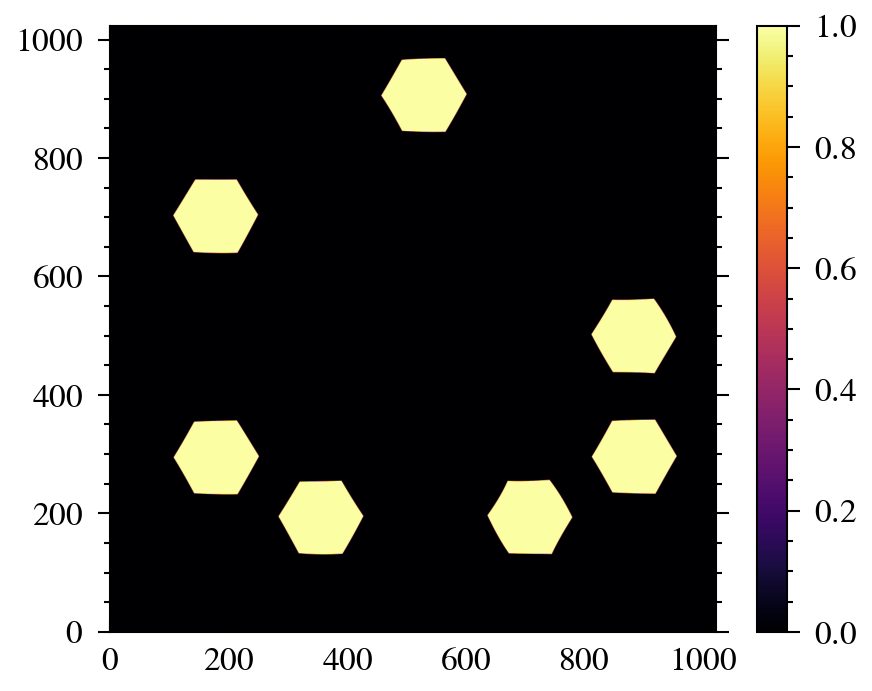

In [3]:
load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()  # helper function

state = load_dict(amigo_files_path + "/calibration.npy")
transmission = state["transmission"]

plt.imshow(transmission)
plt.colorbar()
plt.show()

In [70]:
import equinox as eqx
from amigo.optical_models import AMIOptics
from tqdm.auto import tqdm
import optax
from zodiax import optimisation as opt

def show_diff(optics):
    this_mask = optics.calc_mask(optics.wf_npixels, optics.diameter)

    plt.imshow(this_mask - transmission, cmap=seismic, norm=mpl.colors.CenteredNorm())
    plt.colorbar()
    plt.show()

def loss_fn(params, args, return_im=False):
    optics, transmission = args

    for key, val in params.items():
        optics = optics.set(key, val)
    
    mask = optics.calc_mask(optics.wf_npixels, optics.diameter)
    ll_im = -jax.scipy.stats.norm.logpdf(mask, transmission)
    if return_im:
        return ll_im
    else:
        return ll_im.sum()

optics = AMIOptics(static=False)

loss_grad_fn = eqx.filter_value_and_grad(loss_fn)


# Define our optimisers that we map to each parameter
optimisers = {
    "distortion": optax.sgd(1e-10, momentum=0.5),
    "primary_beam": optax.sgd(1e-6, momentum=0.5),
}

params = {key: np.zeros_like(optics.get(key)) for key in optimisers.keys()}
args = optics, transmission
ll_im = loss_fn(params, args, return_im=True)

# Now we map the optimisers to the parameters and get the initial state
optim, state = opt.map_optimisers(params, optimisers)

epochs = 500

losses = []
param_list = []
with tqdm(range(epochs)) as pbar:
    for step in pbar:
        loss, grads = loss_grad_fn(params, args)
        updates, state = optim.update(grads, state)
        params = optax.apply_updates(params, updates)
        losses.append(loss)
        param_list.append(params)
        pbar.set_postfix(loss=f"{loss:.4f}")
losses = np.array(losses)

  0%|          | 0/500 [00:00<?, ?it/s]

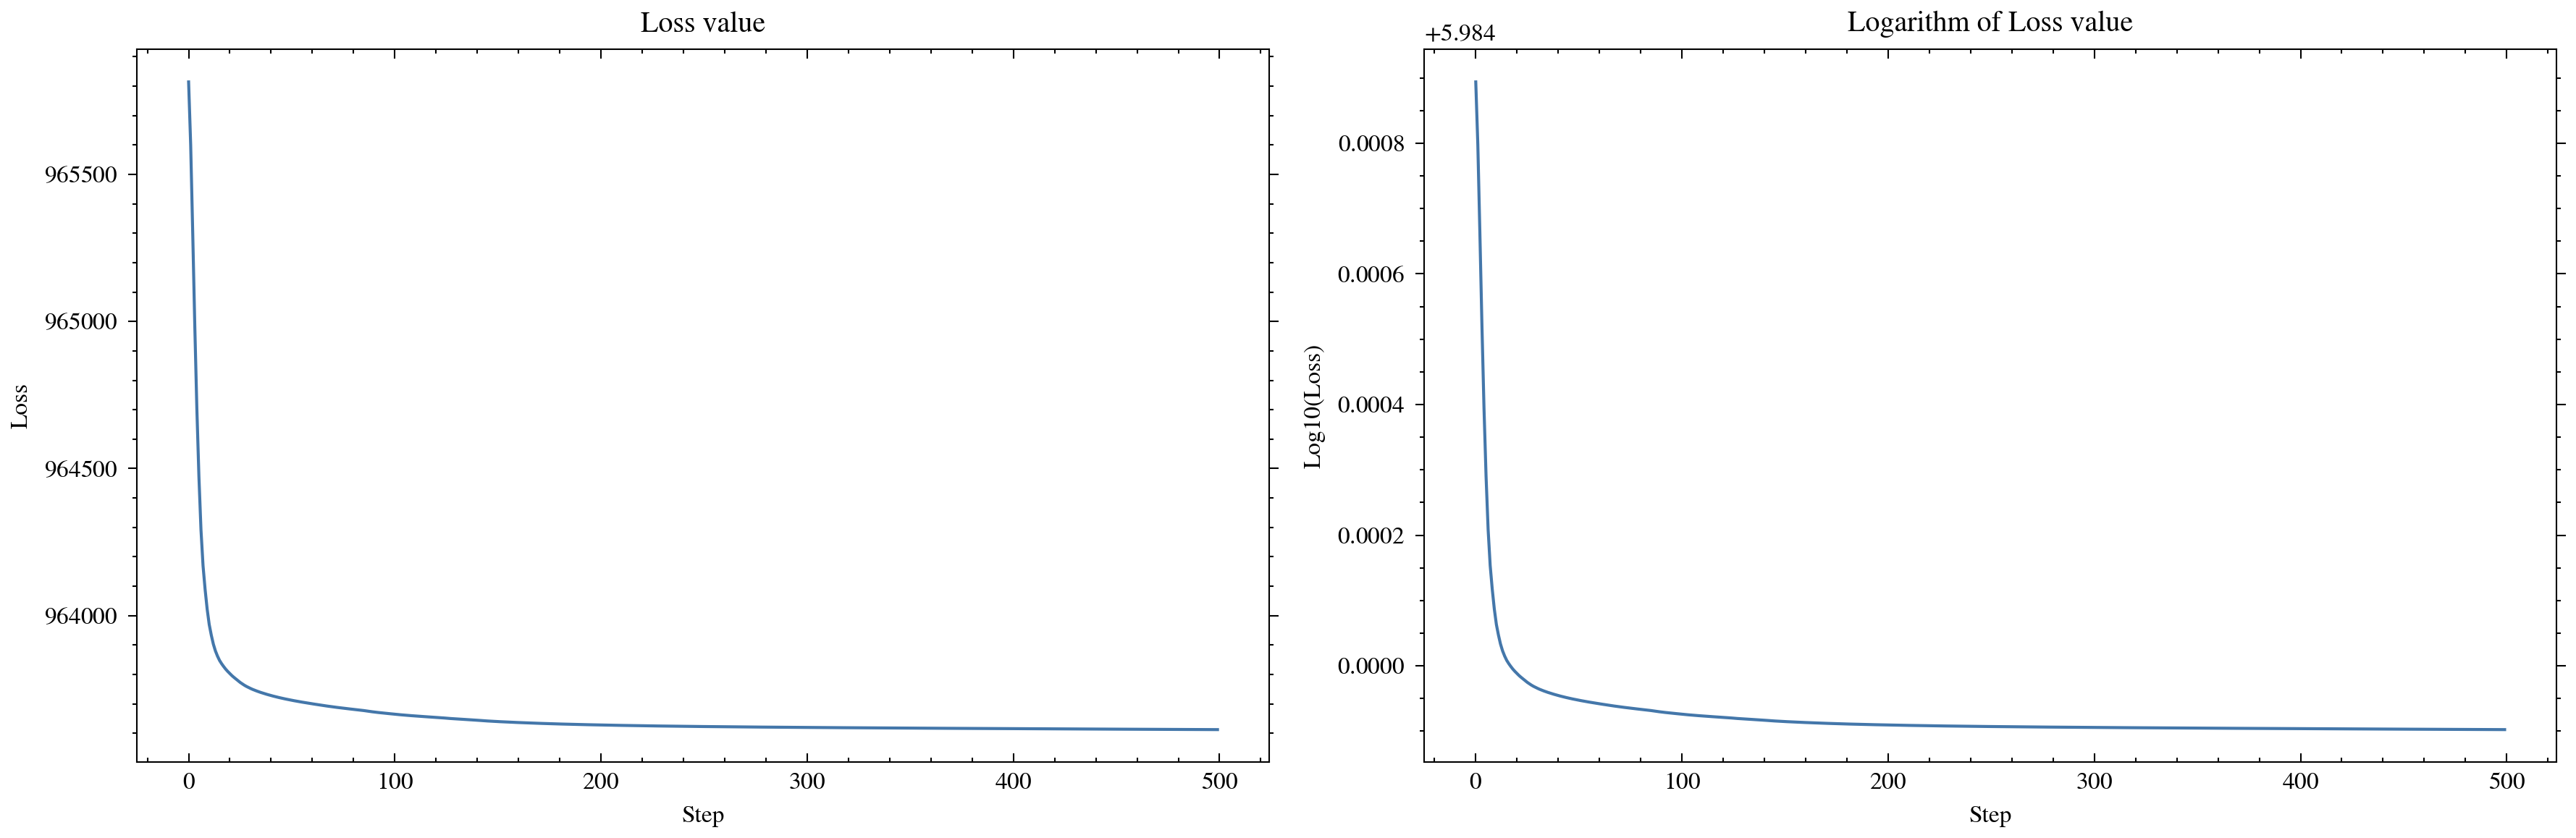

In [71]:
plt.figure(figsize=(12, 4))
ax = plt.subplot(1, 2, 1)
ax.plot(losses)
ax.set(title="Loss value", xlabel="Step", ylabel="Loss")

ax = plt.subplot(1, 2, 2)
ax.plot(np.log10(losses))
ax.set(title="Logarithm of Loss value", xlabel="Step", ylabel="Log10(Loss)")

plt.tight_layout()
plt.show()



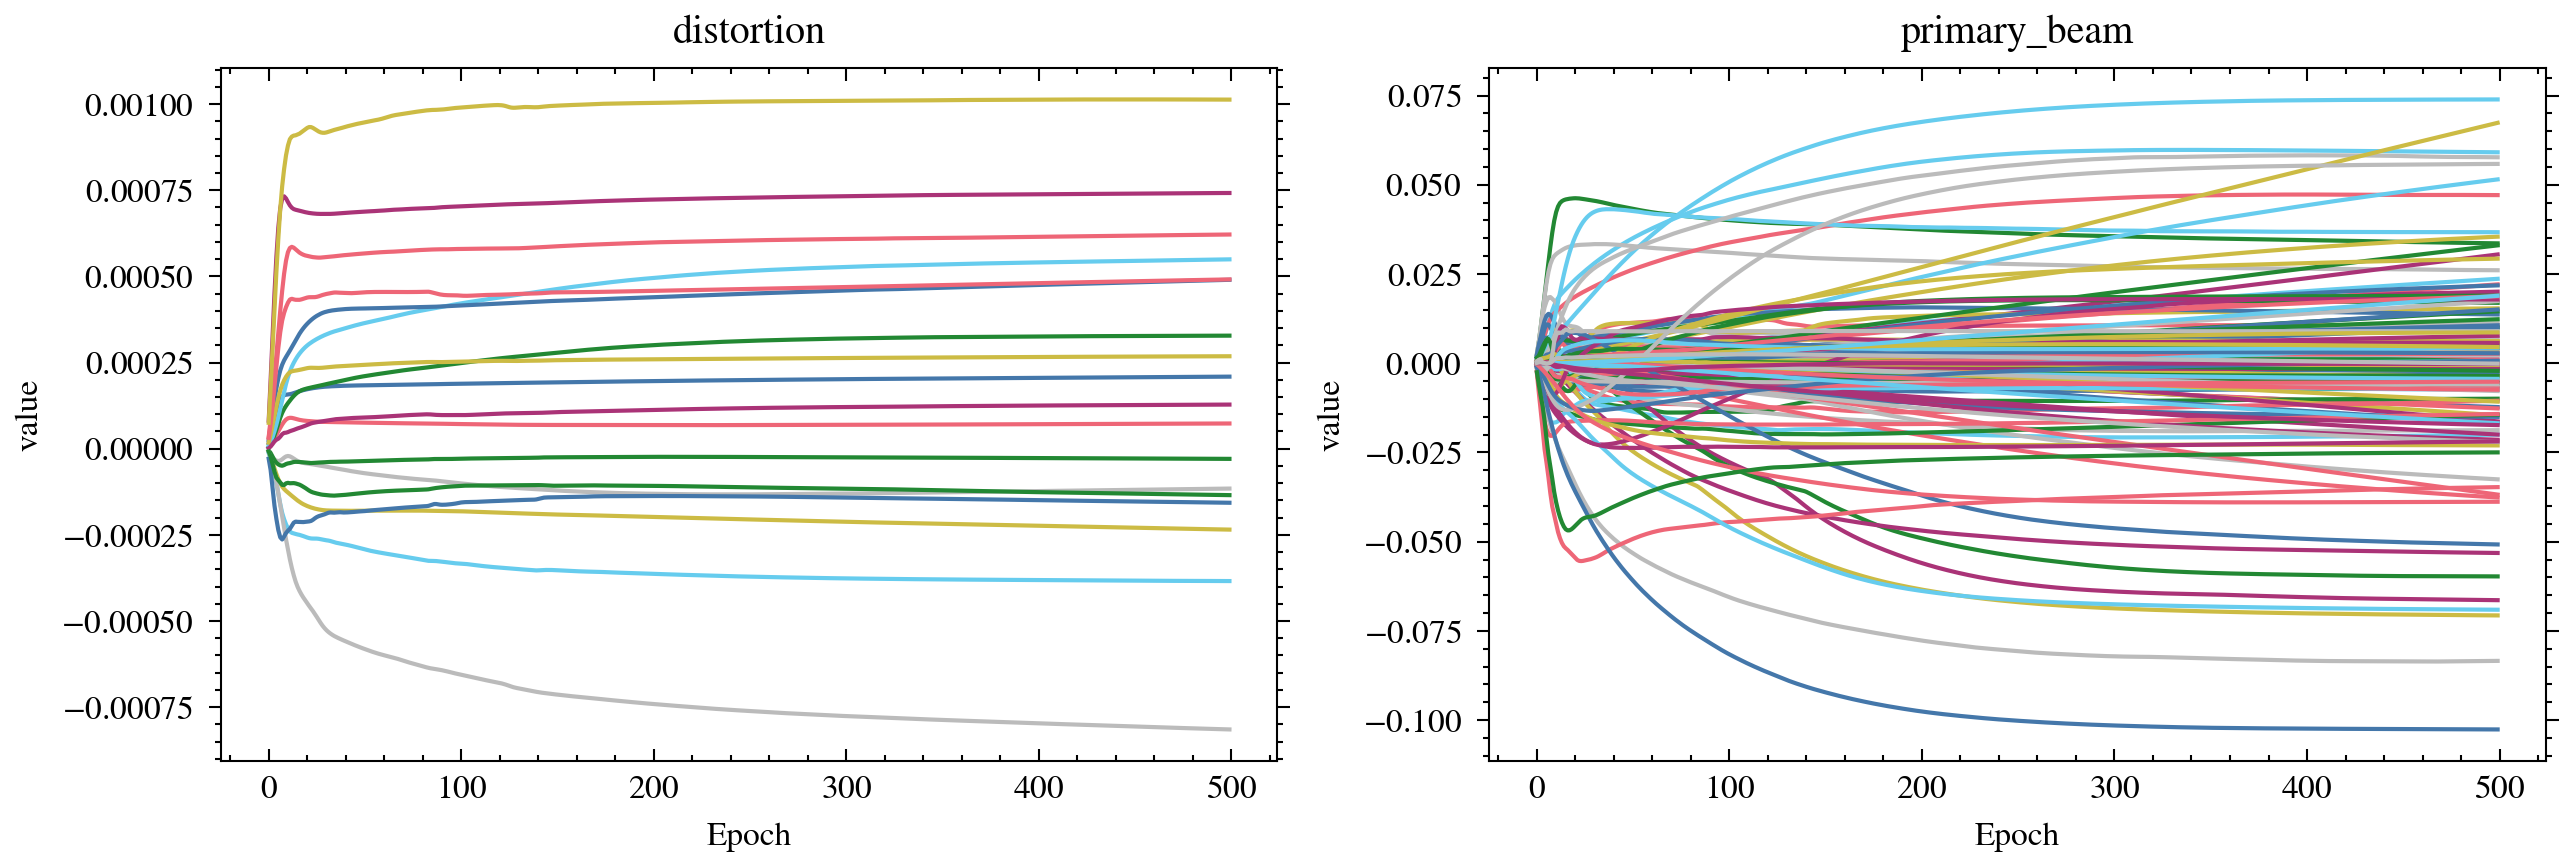

In [72]:
# Stack distortion arrays -> shape: (N, 2, 9)
distortions = np.stack([d['distortion'].ravel() for d in param_list], axis=0)

# Stack primary_beam arrays -> shape: (N, 7, 2, 9)
primary_beams = np.stack([d['primary_beam'].ravel() for d in param_list], axis=0)


fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(distortions)
ax[0].set(
    title="distortion",
    xlabel="Epoch",
    ylabel="value",
)
ax[1].plot(primary_beams)
ax[1].set(
    title="primary_beam",
    xlabel="Epoch",
    ylabel="value",
)
plt.show()

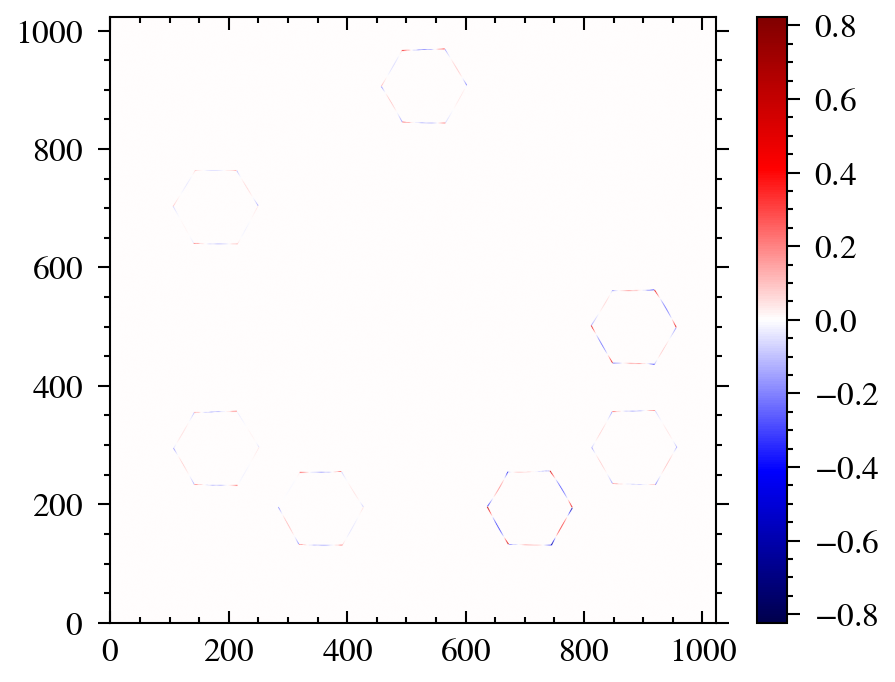

In [75]:
final_params = param_list[-1]

_optics = optics.set([*final_params.keys()], [*final_params.values()])

show_diff(_optics)